In [1]:
!pip install ultralytics -q
!pip install paddlepaddle==3.0.0 -q
!pip install paddleocr -q
!pip install langchain_text_splitters -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 16.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.9/192.9 MB 8.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.7/80.7 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.4/68.4 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.8/120.8 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 31.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 767.5/767.5 kB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 MB 25.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 101.4 MB/s eta 0:00:0000:01
   ━━━

In [2]:
import os
import cv2
import torch
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from torchvision.io import read_image
import matplotlib.patches as patches
from pathlib import Path
from glob import glob
import shutil
import yaml

from ultralytics import YOLO

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
cpu


In [3]:
df1 = pd.read_csv('/kaggle/input/datasets/margaritabasalaeva/lenta-dataset/25_12-20/25_12-20.csv')
df2 = pd.read_csv('/kaggle/input/datasets/margaritabasalaeva/lenta-dataset/26_12-20/26_12-20.csv')
df3 = pd.read_csv('/kaggle/input/datasets/margaritabasalaeva/lenta-dataset/43_15/43_15.csv')

In [4]:
for c1, c2, c3 in zip(df1.columns, df2.columns, df3.columns):
    if c1 != c2 or c1!=c3 or c2!=c3:
        print("Не совпадает:")
        print("df1:", repr(c1))
        print("df2:", repr(c2))
        print("df3:", repr(c3))

Не совпадает:
df1: 'wholesale_level_1_count'
df2: 'wholesale_level_1_coun'
df3: 'wholesale_level_1_coun'


In [5]:
df3.rename(columns={'wholesale_level_1_coun':'wholesale_level_1_count'}, inplace=True)
df2.rename(columns={'wholesale_level_1_coun':'wholesale_level_1_count'}, inplace=True)

In [6]:
df1.columns

Index(['filename', 'product_name', 'price_default', 'price_card',
       'price_discount', 'barcode', 'discount_amount', 'id_sku',
       'print_datetime', 'code', 'additional_info', 'color', 'special_symbols',
       'frame_timestamp', 'x_min', 'y_min', 'x_max', 'y_max',
       'qr_code_barcode', 'price1_qr', 'price2_qr', 'price3_qr', 'price4_qr',
       'wholesale_level_1_count', 'wholesale_level_1_price',
       'wholesale_level_2_count', 'wholesale_level_2_price', 'action_price_qr',
       'action_code_qr'],
      dtype='object')

In [7]:
type(df1["frame_timestamp"].iloc[0])

numpy.int64

In [8]:
df1['filename'].unique()[0]

'25_12-20/2.mp4'

In [12]:
def clean_video_name(x):
    x = str(x).strip()          
    x = x.split("/")[0]        
    if not x.endswith(".mp4"):
        x += ".mp4"
    return x

dfs = [df1, df2, df3]

for df in dfs:
    df["filename"] = df["filename"].apply(clean_video_name)

df1['filename'].unique()[0]

'25_12-20.mp4'

In [14]:
from pathlib import Path
import cv2

root_dir = Path("/kaggle/input/datasets/margaritabasalaeva/lenta-dataset")
out_dir = Path("/kaggle/working/all_frames")
out_dir.mkdir(exist_ok=True)

dfs = [df1, df2, df3]

for df in dfs:

    df["frame_timestamp"] = df["frame_timestamp"].astype(float)

    video_name = str(df["filename"].iloc[0])

    print("Обрабатываю:", repr(video_name))

    video_name = df["filename"].iloc[0]

    video_path = next(root_dir.rglob(video_name))
    print("Нашёл видео:", video_path)

    cap = cv2.VideoCapture(str(video_path))

    fps = cap.get(cv2.CAP_PROP_FPS)
    print("FPS:", fps)

    times = sorted(df["frame_timestamp"].drop_duplicates())

    save_dir = out_dir / video_path.stem
    save_dir.mkdir(exist_ok=True)

    saved = 0

    for t in times:

        frame_id = int(t * fps / 1000)

        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_id)
        ret, frame = cap.read()

        if ret:
            filename = save_dir / f"{int(t)}.jpg"
            cv2.imwrite(str(filename), frame)
            saved += 1

    print("Сохранено:", saved)

    cap.release()

Обрабатываю: '25_12-20.mp4'
Нашёл: /kaggle/input/datasets/margaritabasalaeva/lenta-dataset/Unlabeled/25_12-20.mp4
FPS: 19.964456690161626
Сохранено: 10
Обрабатываю: '26_12-20.mp4'
Нашёл: /kaggle/input/datasets/margaritabasalaeva/lenta-dataset/26_12-20/26_12-20.mp4
FPS: 19.980056250158363
Сохранено: 15
Обрабатываю: '43_15.mp4'
Нашёл: /kaggle/input/datasets/margaritabasalaeva/lenta-dataset/43_15/43_15.mp4
FPS: 19.94640026221262
Сохранено: 2


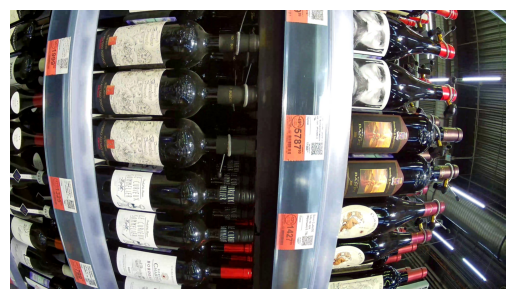

In [182]:
img = cv2.imread('/kaggle/working/all_frames/26_12-20/27156.0.jpg')
plt.axis('off')
plt.imshow(img[:, :, ::-1]);

In [184]:
row = df2[df2['frame_timestamp'] == 27156].iloc[0]

coords = row[['x_min', 'y_min', 'x_max', 'y_max']].astype(str)
coords = coords.str.replace(',', '.').astype(float)

x1, y1, x2, y2 = map(int, coords)
print(x1, y1, x2, y2)

2040 1843 2354 2099


In [185]:
img.shape

(2160, 3840, 3)

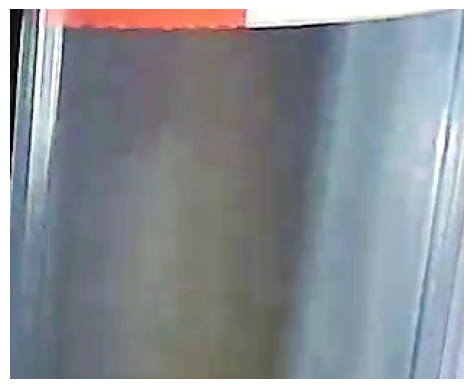

In [190]:
crop = img[y1:y2, x1:x2]
plt.axis('off')
plt.imshow(crop[:, :, ::-1]);
#plt.savefig('crop.jpg')

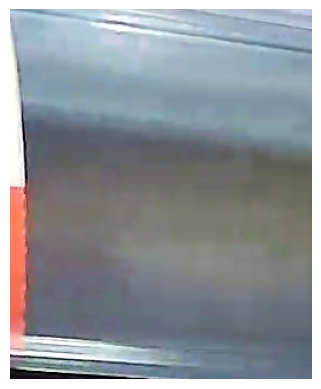

In [187]:
rotated = cv2.rotate(crop, cv2.ROTATE_90_COUNTERCLOCKWISE)
plt.axis("off")
plt.imshow(rotated[:, :, ::-1]);
#plt.savefig('crop.jpg')

In [ ]:
pd.concat([df1, df2, df3], ignore_index = True)

In [3]:
def visualize_bounding_box(image, xmin, ymin, xmax, ymax):
    if isinstance(image, torch.Tensor):
        image_np = image.permute(1, 2, 0).numpy() 
    image_np = image[:, :, ::-1]
    fig, ax = plt.subplots(1)
    ax.imshow(image_np)
    
    width = xmax - xmin
    height = ymax - ymin
    rect = patches.Rectangle((xmin, ymin), width, height, linewidth=2, edgecolor='r', facecolor='none')
    ax.add_patch(rect)
    
    
    # Добавляем точки на изображение
    ax.scatter(xmin, ymin, color='white', s=10, marker='o')
    ax.scatter(xmax, ymax, color='white', s=10, marker='o')
    ax.text(xmin, ymin, f'[{xmin}, {ymin}]', fontsize=10, color='white', ha='right', va='bottom')
    ax.text(xmax, ymax, f'[{xmax}, {ymax}]', fontsize=10, color='white', ha='left', va='top')
    
    ax.xaxis.set_ticks_position('top')
    ax.xaxis.set_label_position('top')
    
    plt.show();

In [ ]:
def pascal_voc_to_yolo_boxes(image, xmin, ymin, xmax, ymax):
    _, height, width = image.shape
    h = [ymax+ymin, ymax-ymin]
    w = [xmax+xmin, xmax-xmin]
    x_center = w[0]/2
    y_center = h[0]/2
    
    x_center_norm = x_center/width
    y_center_norm =  y_center/height
    width_norm = w[1]/width
    height_norm = h[1]/height
    yolo_bbox = [x_center_norm, y_center_norm, width_norm, height_norm]
    
    return yolo_bbox

In [4]:
def enable_determinism():
    os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
    torch.use_deterministic_algorithms(True)

def fix_seeds(seed):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.mps.manual_seed(seed)


enable_determinism()
fix_seeds(24)

In [ ]:
def visualize_yolo_bbox(image_np, bbox):
    print('YOLO формат\n(x_center_normalize, y_center_normalize, width_normalize, height_normalize)')
    print('bbox:\n', bbox)
    fig, ax = plt.subplots(1)
    ax.imshow(image_np)

    h, w, _ = image_np.shape
    x_center, y_center, width, height = bbox

    # Преобразуем нормализованные координаты в пиксели
    x_center_pix = x_center * w
    y_center_pix = y_center * h
    width_pix = width * w
    height_pix = height * h

    xmin = int(x_center_pix - width_pix / 2)
    ymin = int(y_center_pix - height_pix / 2)
    xmax = int(x_center_pix + width_pix / 2)
    ymax = int(y_center_pix + height_pix / 2)

    rect = patches.Rectangle((xmin, ymin), width_pix, height_pix, linewidth=2, edgecolor='r', facecolor='none')
    ax.add_patch(rect)


    # Визуализируем центр
    ax.scatter(x_center_pix, y_center_pix, color='white', s=10, marker='o')
    plt.text(x_center_pix + 5, y_center_pix, f'({round(x_center,2)}, {round(y_center,2)})', fontsize=10, color='white', ha='right', va='bottom')

    plt.text(x_center_pix - 30, ymax + 15, f"Width: {width:.2f}", color='white', fontsize=10)
    plt.text(xmax + 15, y_center_pix, f"Height: {height:.2f}", color='white', fontsize=10)

    # Устанавливаем относительные оси от 0 до 1
    ax.set_xticks(np.linspace(0, w, num=9))  # 6 меток по оси X
    ax.set_yticks(np.linspace(0, h, num=10))  # 6 меток по оси Y

    ax.set_xticklabels(np.linspace(0, 1, num=9), rotation=0)
    ax.set_yticklabels(np.round(np.linspace(0, 1, num=10), 2))  # Переворот для правильного отображения Y
    ax.xaxis.set_ticks_position('top')
    ax.xaxis.set_label_position('top')
    plt.show()

yolo_box = df_train.iloc[0]['x_c':'h'].to_numpy()
visualize_yolo_bbox(img, yolo_box)

In [ ]:
def create_dataset_template(path_to_create_dataset_template):
    new_dataset_path = Path(path_to_create_dataset_template)
    new_dataset_path.mkdir(exist_ok=True)
    
    path_to_train_images = Path(new_dataset_path, 'images', 'train')
    path_to_train_images.mkdir(exist_ok=True, parents=True,)
    
    path_to_train_labels = Path(new_dataset_path, 'labels', 'train')
    path_to_train_labels.mkdir(exist_ok=True, parents=True,)
    
    path_to_val_images = Path(new_dataset_path, 'images', 'val')
    path_to_val_images.mkdir(exist_ok=True, parents=True,)
    
    path_to_val_labels = Path(new_dataset_path, 'labels', 'val')
    path_to_val_labels.mkdir(exist_ok=True, parents=True,)
    
    absolute_path_to_dataset = new_dataset_path.resolve()
    absolute_path_to_train_images = path_to_train_images.resolve()
    absolute_path_to_train_labels = path_to_train_labels.resolve()
    absolute_path_to_val_images = path_to_val_images.resolve()
    absolute_path_to_val_labels = path_to_val_labels.resolve()
    
    return absolute_path_to_dataset, absolute_path_to_train_images, absolute_path_to_train_labels, absolute_path_to_val_images, absolute_path_to_val_labels

In [ ]:
path_to_create_dataset_template = '/kaggle/working/dataset_plate' 
path_to_dataset, path_to_train_images, path_to_train_labels, path_to_val_images, path_to_val_labels = create_dataset_template(path_to_create_dataset_template)

In [ ]:
def prepare_dataset(df, path_to_save_images, path_to_save_labels):
    for index, row in df.iterrows():
        image_path = Path(row['image_path'])
        image_name = image_path.stem
        save_path_image = Path(path_to_save_images, image_path.name)
        if not save_path_image.exists():
            shutil.copy(image_path, save_path_image)
        yolo_boxes_str = f"0 {row['x_c']} {row['y_c']} {row['w']} {row['h']}\n"
        path_to_annotation = Path(path_to_save_labels, f'{image_name}.txt')
        with open(path_to_annotation, 'a') as f_out:
            f_out.write(yolo_boxes_str)


prepare_dataset(df_train, path_to_train_images, path_to_train_labels)
prepare_dataset(df_val, path_to_val_images, path_to_val_labels)

In [ ]:
def generate_yaml_config(dataset_path, path_to_train, path_to_val):
    config = {
        'path': str(dataset_path), # абсолютный путь к датасету
        'train': str(path_to_train.relative_to(dataset_path)), # путь к train-изображениям относительно dataset_path
        'val': str(path_to_val.relative_to(dataset_path)), # # путь к val-изображениям относительно dataset_path
        'names': {
            '0': 'plate'
            },
    
    }
    path_to_config = Path('config.yaml')
    with open('config.yaml', 'w') as file:
        yaml.dump(config, file)
    absolute_path_to_config = path_to_config.resolve()
    return absolute_path_to_config

generate_yaml_config(path_to_dataset, path_to_train_images, path_to_val_images)

In [ ]:
model = YOLO('yolo11s.pt')

In [ ]:
hparams = {
    "degrees": 3.0,        
    "translate": 0.02,     
    "scale": 0.05,       
    "shear": 0.5,        
    "perspective": 0.0005, 
    "flipud": 0.0,        
    "fliplr": 0.0,       
    "hsv_h": 0.01,
    "hsv_s": 0.25,
    "hsv_v": 0.15,
    "mosaic": 0.02,    
    "mixup": 0.00,   
}

In [ ]:
train_results = model.train(data='config.yaml', epochs=100, imgsz=1280, batch=8, rect=True, optimizer="AdamW", lr0=0.0001, **hparams)

In [ ]:
im = cv2.imread('/kaggle/input/car-plate/data_jpg/images/test/000103_0.jpg')
results = model.predict(source=im, save=True)

In [48]:
import os
import cv2
import torch
import random

import matplotlib.pyplot as plt
import re

from paddleocr import PaddleOCR

In [50]:
ocr = PaddleOCR(
    use_textline_orientation=True,
    lang='ru',
    text_det_limit_side_len=960
)

/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:711: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Creating model: ('PP-LCNet_x1_0_doc_ori', None, None)
Checking connectivity to the model hosters, this may take a while. To bypass this check, set `PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK` to `True`.
Using official model (PP-LCNet_x1_0_doc_ori), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Creating model: ('UVDoc', None, None)
Using official model (UVDoc), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/UVDoc`.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Creating model: ('PP-LCNet_x1_0_textline_ori', None, None)
Using official model (PP-LCNet_x1_0_textline_ori), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-LCNet_x1_0_textline_ori`.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Creating model: ('PP-OCRv5_server_det', None, None)
Using official model (PP-OCRv5_server_det), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-OCRv5_server_det`.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Creating model: ('eslav_PP-OCRv5_mobile_rec', None, None)
Using official model (eslav_PP-OCRv5_mobile_rec), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/eslav_PP-OCRv5_mobile_rec`.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

In [148]:
results = ocr.predict(rotated)

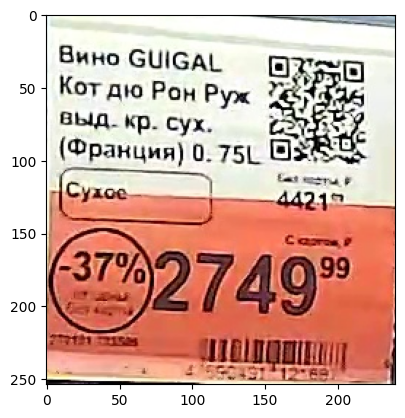

In [149]:
plt.imshow(rotated[:, :, ::-1])

In [151]:
row

filename                                                        26_12-20.mp4
product_name               Вино GUIGAL Кот дю Рон Руж выд. кр. сух. (Фран...
price_default                                                        4421,09
price_card                                                           2749,99
price_discount                                                           нет
barcode                                                      4690491121887.0
discount_amount                                                         -37%
id_sku                                                        270101730056.0
print_datetime                                               17.02.2026 1:14
code                                                                     нет
additional_info                                                        Сухое
color                                                                    red
special_symbols                                                          нет

In [150]:
print(results[0]['rec_texts'])

['Вино (', 'GUIGAL', 'Кот дю Рон Руж', 'выд.', 'kр. cyx.', 'Франция) 0.75L', 'La74', 'Сyxое', '4421', '27', '37%', '2749', '99']
